In [48]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [49]:
G=M=c=1
m1=m2=0.5

n1=[0,1,0]


In [63]:
def f(t,y):#y=x1,vx1,...,x2, vx2,....
    r1=np.array([y[0], y[2],y[4]])  #prodotto scalare np.dot
    r2=np.array([y[6], y[8], y[10]])

    v1=np.array([y[1], y[3], y[5]])
    v2=np.array([y[7], y[9], y[11]])

    r12=np.sqrt(np.dot(r1-r2, r1-r2)) #modulo
    
    n12=(r1-r2)/r12 #versore

    v12=v1-v2

    T1=-G*m2/r12**2*n12

    T2=208*G**3*m1*m2**2/(15*r12**4)*np.dot(n12,v12)

    T3=-24*G**3*m1**2*m2/(5*r12**4)*np.dot(n12, v12)

    T4=12*G**2*m1*m2/(5*r12**3)*np.dot(n12, v12)*np.dot(v12,v12)

    T5=8*G**3*m1**2*m2/(5*r12**4)

    T6=-32*G**3*m1*m2**2/(5*r12**4)

    T7=-4*G**2*m1*m2/(5*r12**3)*np.dot(v12, v12)

    a1=T1+1/c**5*((T2+T3+T4)* n12 + (T5+T6+T7)*v12)

    n21=-n12
    v21=-v12

    T8=-G*m1/r12**2*n21

    a2=T8+1/c**5*((T2+T3+T4)* n21 + (T5+T6+T7)*v21)

    deriv=np.array([v1[0], a1[0], v1[1], a1[1], v1[2], a1[2], v2[0], a2[0], v2[1], a2[1], v2[2], a2[2]])

    return deriv


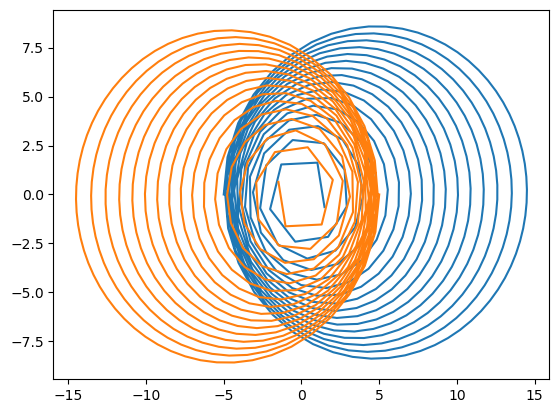

In [65]:
from scipy.integrate import solve_ivp

#condizioni iniziali
tf=10000
t_eval=np.linspace(0, tf, 1000)

t_span=[0,tf]

atoll=10**(-10)
rtoll=atoll

e=0.5
a=20
vy1=m2/(m1+m2)*np.sqrt(G*(m1+m2)/a*(1+e)/(1-e))
vy2=m1/(m1+m2)*np.sqrt(G*(m1+m2)/a*(1+e)/(1-e))

y0=[-a*(1-e)/2, 0, 0, vy1, 0, 0, a*(1-e)/2, 0, 0, -vy2, 0, 0]


def isco(t, y):
    r12=np.sqrt((y[0]-y[6])**2+(y[2]-y[8])**2+(y[4]-y[10])**2) #separazione relativa
    if m1>=m2:
        return r12-6*G*m1/c**2
    if m2>m1:
        return r12-6*G*m2/c**2
isco.terminal = True
isco.direction = -1

out=solve_ivp(f,t_span, y0, method='RK45', t_eval=t_eval, rtol=10**(-10), atol=10**(-10), events=isco)
#con onde gravitazionali usiamo RK perche energia non è conservata, ma per ridurre errore secolare mettiamo una tolleranza molto piccola

y=out['y']


plt.plot(y[0], y[2])
plt.plot(y[6], y[8])


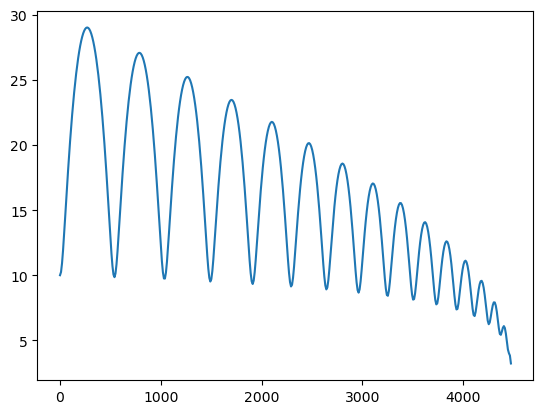

In [66]:
#separazione relativa
r12=np.sqrt((y[0]-y[6])**2+(y[2]-y[8])**2+(y[4]-y[10])**2)
t=out['t']

plt.plot(t, r12)

(448, 3)
(448,)


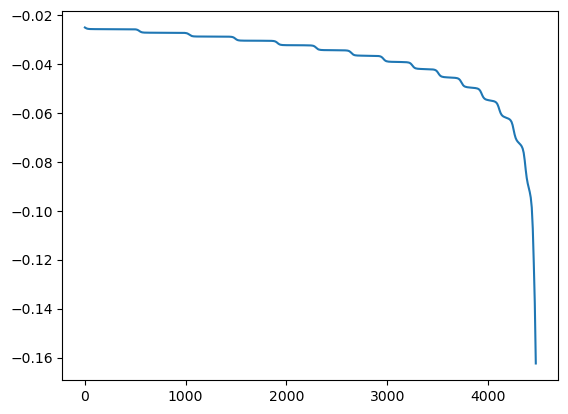

In [ ]:
r12=np.sqrt((y[0]-y[6])**2+(y[2]-y[8])**2+(y[4]-y[10])**2).T
r=np.array([y[0]-y[6], y[2]-y[8], y[4]-y[10]]).T
print(np.shape(r))
v12=np.sqrt((y[1]-y[7])**2+(y[3]-y[9])**2+(y[5]-y[11])**2).T
v=np.array([y[1]-y[7], y[3]-y[9], y[5]-y[11]]).T

eps=v12**2/2-G*(m1+m2)/r12

a=-G*(m1+m2)/(2*eps)

harray=np.array([])

for i in range(len(t)):
    h=np.cross(r[i,:],v[i,:])
    h2=np.dot(h,h)
    harray=np.append(harray,h2)

print(np.shape(harray))

e=np.sqrt(1-harray/(G*(m1+m2)*a))

plt.plot(t, eps)

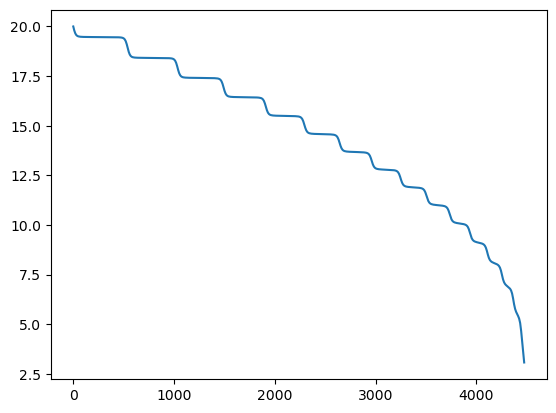

In [79]:
plt.plot(t, a)

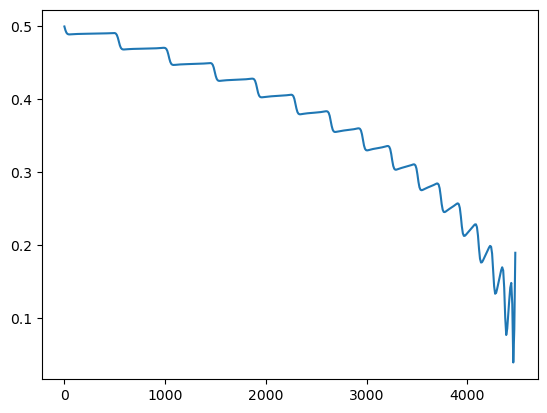

In [80]:
plt.plot(t,e)